In [82]:
import torch
from dinosaw.helpers import ModelTypes, model_names, get_models, get_features
from dinosaw.utils import do_2D_pca

import numpy as np
from tifffile import imread
from PIL import Image

from skimage.transform import resize

import matplotlib.pyplot as plt
from typing import TypeAlias, Literal

from interactive_seg_backend import TrainingConfig, FeatureConfig, featurise, concat_feats, train_and_apply
from interactive_seg_backend.file_handling import load_labels

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False

In [ ]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'dvt', 'alibi_dv2_h')
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

f_cfg = FeatureConfig()
tr_cfg = TrainingConfig(feature_config=f_cfg, CRF=True, classifier='xgb', CRF_params={"label_confidence": 0.6,
    "sxy_g": [1, 1],
    "sxy_b": [30, 30],
    "s_rgb": [13, 13, 13],
    "compat_g": 10,
    "compat_b": 10,
    "n_infer": 10}, classifier_params={"class_weight": "balanced", "max_depth": 8}) 

In [84]:
ds_folder = 'data/trainable_seg'

AllowedImages = Literal['anode', 'curtains', 'bimodal', 'NMC', 'steel']


side_lengths: dict[AllowedImages, int] = {
    'anode': 756,
    'curtains': 756,
    'bimodal': 839,
    'NMC': 602,
    'steel': 602,
}


image_fnames: list[AllowedImages] = ['anode', 'anode']
images: list[Image.Image] = []
labels: list[np.ndarray] = []
for image_fname in image_fnames:
    img = Image.open(f"{ds_folder}/{image_fname}.png").convert("RGB")
    shortest = min(img.size)
    L = side_lengths[image_fname]
    sf = L / shortest
    new_size = (int(img.size[0] * sf), int(img.size[1] * sf))
    img = img.resize(new_size, resample=Image.BILINEAR)
    images.append(img)

    label = load_labels(f"{ds_folder}/{image_fname}_biased_labels.tiff")
    labels.append(label)

In [85]:
features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}
red_features: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}


for key, model in models.items():
    for img in images:
        feats = get_features(model, img, False, False,  device=DEVICE)
        reduced = do_2D_pca(feats, 9, pre_norm='std', post_norm='minmax')
        reduced_hr = resize(reduced, (img.height, img.width), order=1, mode='reflect', anti_aliasing=True)

        classical = featurise(np.array(img.convert('L')), tr_cfg)

        combined_feats = concat_feats(reduced_hr, classical)
        features[key].append(combined_feats)

        red_features[key].append(reduced_hr)

2026-02-24 20:34:11 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-02-24 20:34:13 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-02-24 20:34:15 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features
2026-02-24 20:34:18 | I | multiscale_classical_cpu.py:426 | CPU feats on (756, 1319) with `default`: weka-style features


In [86]:
preds: dict[ModelTypes, list[np.ndarray]] = {k: [] for k in enabled_models}

for key, model in models.items():
    for i, feat in enumerate(features[key]):
        image = np.array(images[i])
        label = labels[i]

        pred, _, _ = train_and_apply(feat, label, tr_cfg, image=image)
        preds[key].append(pred)

2026-02-24 20:34:19 | I | core.py                    :122 | Training XGBClassifier: (1844, 67) -> ((1844,)) 
2026-02-24 20:34:19 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-02-24 20:34:20 | I | crf.py                     :77 | CRF: probs (756, 1319, 3), img (756, 1319, 3), params: {
  "label_confidence": 0.6,
  "sxy_g": [
    1,
    1
  ],
  "sxy_b": [
    30,
    30
  ],
  "s_rgb": [
    13,
    13,
    13
  ],
  "compat_g": 10.0,
  "compat_b": 10.0,
  "n_infer": 10
}


[20:34:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.



2026-02-24 20:34:21 | I | core.py                    :122 | Training XGBClassifier: (1844, 67) -> ((1844,)) 
2026-02-24 20:34:21 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-02-24 20:34:21 | I | crf.py                     :77 | CRF: probs (756, 1319, 3), img (756, 1319, 3), params: {
  "label_confidence": 0.6,
  "sxy_g": [
    1,
    1
  ],
  "sxy_b": [
    30,
    30
  ],
  "s_rgb": [
    13,
    13,
    13
  ],
  "compat_g": 10.0,
  "compat_b": 10.0,
  "n_infer": 10
}


[20:34:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.



2026-02-24 20:34:23 | I | core.py                    :122 | Training XGBClassifier: (1844, 67) -> ((1844,)) 
2026-02-24 20:34:23 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-02-24 20:34:23 | I | crf.py                     :77 | CRF: probs (756, 1319, 3), img (756, 1319, 3), params: {
  "label_confidence": 0.6,
  "sxy_g": [
    1,
    1
  ],
  "sxy_b": [
    30,
    30
  ],
  "s_rgb": [
    13,
    13,
    13
  ],
  "compat_g": 10.0,
  "compat_b": 10.0,
  "n_infer": 10
}


[20:34:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.



2026-02-24 20:34:25 | I | core.py                    :122 | Training XGBClassifier: (1844, 67) -> ((1844,)) 
2026-02-24 20:34:25 | I | core.py                    :137 | Applying XGBClassifier to (756, 1319, 67) features
2026-02-24 20:34:25 | I | crf.py                     :77 | CRF: probs (756, 1319, 3), img (756, 1319, 3), params: {
  "label_confidence": 0.6,
  "sxy_g": [
    1,
    1
  ],
  "sxy_b": [
    30,
    30
  ],
  "s_rgb": [
    13,
    13,
    13
  ],
  "compat_g": 10.0,
  "compat_b": 10.0,
  "n_infer": 10
}


[20:34:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.



In [87]:
def hide_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])

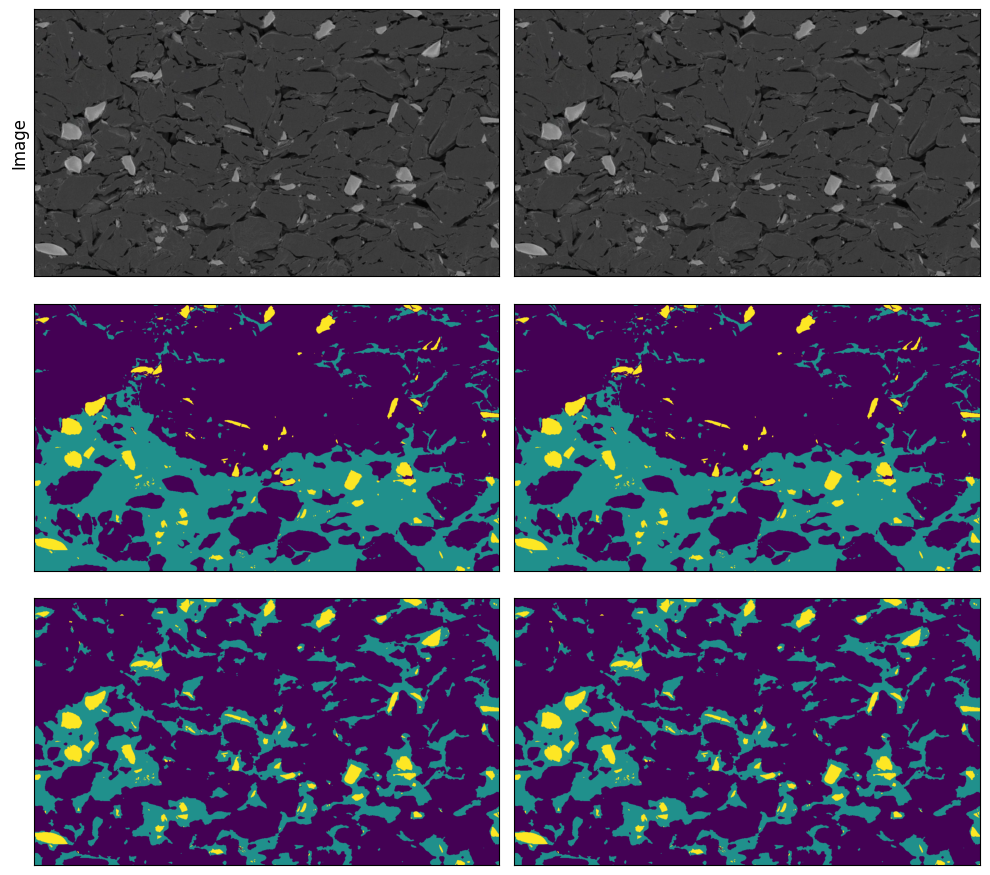

In [88]:
N_ROWS = len(enabled_models) + 1
N_COLS = len(image_fnames)
fig, axs = plt.subplots(N_ROWS, N_COLS, figsize=(5 * N_COLS, 3 * N_ROWS))

for y in range(N_ROWS):
    for x in range(N_COLS):
        if y == 0:
            axs[y, 0].set_ylabel("Image", fontsize=12)
            arr = images[0]
        else:
            key = enabled_models[y-1]
            arr = preds[key][x]
        axs[y, x].imshow(arr)
        hide_axis(axs[y, x])

plt.tight_layout()